In [43]:
import pickle
import pandas as pd
import json
import os
import pprint
from tqdm import tqdm
from pandas import json_normalize
import matplotlib.pyplot as plt

from sankeyflow import Sankey
import matplotlib.pyplot as plt
from itertools import product

import matplotlib.colors as colors
import numpy as np
import seaborn as sns


In [44]:
from adr import adr
import utils

In [45]:
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle' 

# KRUCHTEN_RESULTS = "./data/responses_KRUCHTEN_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# QUALITY_ATTRIBUTE_RESULTS = "./data/responses_QUALITY_ATTRIBUTES_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# ZIMMERMANN_RESULTS = "./data/responses_ZIMMERMANN_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# COMPLIANCE_RESULTS = "./data/responses_CONSISTENCY_ANALYSIS_all_gpt-4.1-nano__LLM4ADR-adrs_english__edit.pickle"

# KRUCHTEN_RESULTS = "../sample/kruchten_gt_processed1_static_few_shots_classification_results_gt.json"
# KRUCHTEN_RESULTS = "../sample/kruchten_gt_processed1_checked1_dynamic_few_shot_results.json"
KRUCHTEN_RESULTS = "../results/all_projects-krutchen_classification_results.json"

# QUALITY_ATTRIBUTE_RESULTS = "../sample/qas_gt_processed1_static_few_shots_classification_results_gt.json"
QUALITY_ATTRIBUTE_RESULTS = "../results/all_projects-qas_classification_results.json"

# ZIMMERMANN_RESULTS = "../sample/zimmermann_gt_processed1_static_few_shots_classification_results_gt.json"
ZIMMERMANN_RESULTS = "../results/all_projects-zimmermann_classification_results.json"

# TOPICS_RESULTS = "../sample/kruchten_gt_processed1-topics.json"
TOPICS_RESULTS = "../results/all_projects-topics.json"

# COMPLIANCE_RESULTS = "./data/responses_CONSISTENCY_ANALYSIS_all_gpt-4.1-nano__LLM4ADR-adrs_english__edit.pickle"
# COMPLIANCE_RESULTS = "../sample/checking_results_all_adrs.json"
COMPLIANCE_RESULTS = "../results/all_projects-checks_results.json"

COMMON_PALETTE = plt.cm.Set3

In [46]:
def create_pie_chart(df: pd.DataFrame, palette, title: str="", show_legend=False, category_column='primary_category'):
    # Make a radar chart by primary_category, including percentage of each category
    df_counter = df[category_column].value_counts()
    if show_legend:
        df_counter.plot(kind='pie', autopct='%1.1f%%', cmap=palette, labels=None)
        plt.legend(df_counter.index, loc='upper left', bbox_to_anchor=(1, 1))
    else:
        df_counter.plot(kind='pie', autopct='%1.1f%%', cmap=palette)
    plt.title(title)
    plt.ylabel('')
    plt.show()

def create_bar_chart(df: pd.DataFrame, palette, title: str="", show_legend=False,
                    category_column="primary_category", fig_size=(8, 3), col_width=0.8):
    # Make a radar chart by primary_category, including percentage of each category
    df_counter = df[category_column].value_counts(normalize=True)
    categories = df_counter.index.tolist()
    percentages = df_counter.mul(100).sort_values(ascending=True)

    # Create the plot
    plt.figure(figsize=fig_size)
    my_colors = [colors.to_hex(rgba) for rgba in palette.colors]
    ax = percentages.plot(kind='barh', width=col_width, color=my_colors)

    # Add percentage labels to the bars
    for index, value in enumerate(percentages):
        # Place the text at the end of each bar
        ax.text(value, index, f'{value:.1f}%', va='center', ha='left', fontsize=10)
    
    plt.title(title)
    plt.xlim(0, 100)
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

In [47]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


---

### **Classification using Kruchten Taxonomy**

In [48]:
with open(KRUCHTEN_RESULTS,'rb') as file:
    kurchten_classification_dict_list = json.load(file)

print(len(kurchten_classification_dict_list), "ADRs")
kurchten_classification_dict_list[0:10]


4213 ADRs


[{'framework': 'kruchten',
  'primary_category': 'Executive (pericrisis)',
  'explanation': 'The ADR focuses on adopting Lightweight Architectural Decision Records (LADRs) as a recommended practice for documenting decisions and rationale in the development process. It is about how the team works and documents architectural decisions rather than about creating or forbidding specific architectural elements or setting system properties. Therefore, it fits best into the Executive category, which governs development processes and organizational practices. It is not an Existence decision because it does not create or select system elements; not a Ban/Non-Existence decision because it does not forbid elements; and not a Property decision because it does not set system qualities or constraints.',
  'primary_score': 0.9,
  'alternative_categories': ['Existence (ontocrisis)'],
  'alternative_confidence_scores': [0.1],
  'metadata': {'organization': 'chunksnbits',
   'project': 'tooling',
   'adr

In [49]:
# krutchen_df = pd.DataFrame(kurchten_classification_dict_list)
krutchen_df = pd.json_normalize(kurchten_classification_dict_list)
krutchen_df


,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,kruchten,Executive (pericrisis),The ADR focuses on adopting Lightweight Archit...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0001-use-architectural-decision-records.md
1,kruchten,Executive (pericrisis),The ADR decision is about adopting 'husky' as ...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0002-use-husky-for-git-hooks.md
2,kruchten,Executive (pericrisis),The ADR focuses on standardizing the commit me...,0.90,[Property (diacrisis)],[0.1],chunksnbits,tooling,0003-use-commitizen-commitlint.md
3,kruchten,Executive (pericrisis),The ADR decision is about adopting a tool (sta...,0.85,[Property (diacrisis)],[0.15],chunksnbits,tooling,0004-use-standard-version-for-versioning.md
4,kruchten,Executive (pericrisis),The ADR decision is about adopting TypeScript ...,0.85,[Existence (ontocrisis)],[0.15],chunksnbits,tooling,0005-use-typescript-in-javascript-projects.md
...,...,...,...,...,...,...,...,...,...
4208,kruchten,Property (diacrisis),The ADR defines rules about the behavior of he...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0009-dos-and-donts-for-building-health-module-...
4209,kruchten,Existence (ontocrisis),The ADR decides that implementation-specific r...,0.85,"[Property (diacrisis), Executive (pericrisis)]","[0.1, 0.05]",avniproject,openchs-adr,0010-all-implementation-rules-will-temporarily...
4210,kruchten,Ban/Non-Existence (anticrisis),The ADR decides to stop using the Forms API to...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0011-moving-forward-forms-api-will-not-be-used...
4211,kruchten,Existence (ontocrisis),The ADR decision is about creating a generic r...,0.90,[Property (diacrisis)],[0.1],avniproject,openchs-adr,0012-create-a-generic-relationship-framework-t...


In [50]:
print(krutchen_df['primary_category'].unique())
# krutchen_df[krutchen_df['primary_category'] == 'Ban/Non-Existence (anticrisis)']

['Executive (pericrisis)' 'Existence (ontocrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']


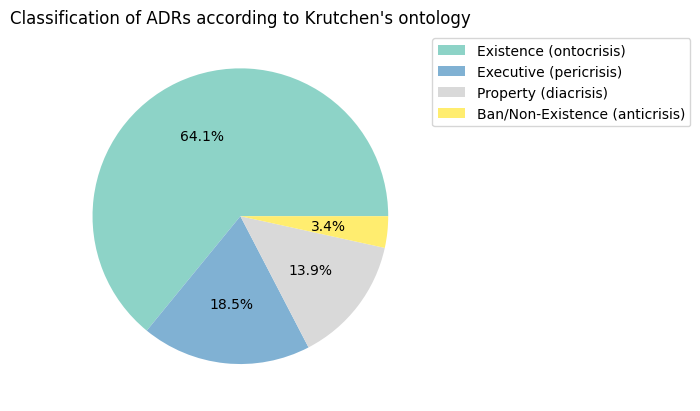

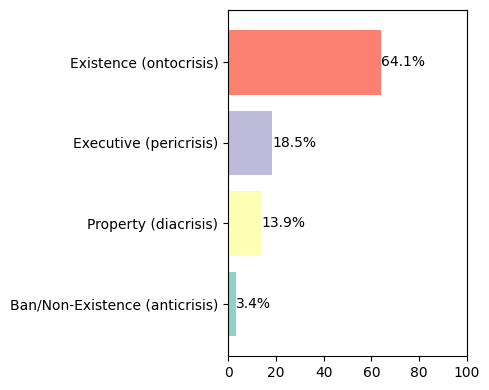

In [51]:
title = "Classification of ADRs according to Krutchen's ontology"

create_pie_chart(krutchen_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(krutchen_df, palette=COMMON_PALETTE, title="", fig_size=(5,4))

---

### **Classification in Quality Attributes**

In [52]:
with open(QUALITY_ATTRIBUTE_RESULTS,'rb') as file:
    qa_classification_dict_list = json.load(file)

print(len(qa_classification_dict_list), "ADRs")
qa_classification_dict_list[0:10]


4316 ADRs


[{'framework': 'quality_attributes',
  'primary_category': 'Maintainability',
  'explanation': "The ADR focuses on extending and refactoring the CLI implementation for Konduit Serving by leveraging Vert.x Launcher. The primary motivation is to improve maintainability aspects such as easier testing, lifecycle management, and reducing maintenance overhead by consolidating CLI implementations from Python to Java. Although there are mentions of deployment options and running multiple instances, these are features of the CLI and Vert.x rather than the system's scalability or performance. The core decision is about structuring the CLI codebase and lifecycle, which aligns with Maintainability rather than Performance, Scalability, or other attributes.",
  'primary_score': 0.9,
  'alternative_categories': ['Performance', 'Scalability'],
  'alternative_confidence_scores': [0.07, 0.03],
  'metadata': {'organization': 'KonduitAI',
   'project': 'konduit-serving',
   'adr_key': '0001-Extend_vertx_l

In [53]:
# qas_df = pd.DataFrame(qa_classification_dict_list)
qas_df = pd.json_normalize(qa_classification_dict_list)

qas_df

,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,quality_attributes,Maintainability,The ADR focuses on extending and refactoring t...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0001-Extend_vertx_launcher_for_CLI.md
1,quality_attributes,Maintainability,The ADR focuses on using Swagger annotations t...,0.90,"[Portability, Usability]","[0.07, 0.03]",KonduitAI,konduit-serving,0002-Use_swagger_annotations_for_generating_cl...
2,quality_attributes,Maintainability,The ADR primarily focuses on redesigning the i...,0.90,"[Performance, Scalability, Usability]","[0.05, 0.03, 0.02]",KonduitAI,konduit-serving,0003-Pipeline_API_Rewrite.md
3,quality_attributes,Maintainability,The ADR primarily focuses on introducing a new...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0004-Graph_pipelines.md
4,quality_attributes,Usability,The ADR primarily focuses on improving the usa...,0.85,"[Reliability, Maintainability]","[0.1, 0.05]",KonduitAI,konduit-serving,0005-Packaging_System_Design.md
...,...,...,...,...,...,...,...,...,...
4311,quality_attributes,Maintainability,The ADR focuses on choosing a framework (Ant D...,0.85,"[Usability, Other/Only Functional Concern]","[0.1, 0.05]",dennisseidel,saas-platform-frontend,0007-use-ant-design-landing-to-create-the-land...
4312,quality_attributes,Other/Only Functional Concern,The ADR describes a decision about how to gene...,1.00,[],[],dennisseidel,saas-platform-frontend,0008-use-launchaco-com-to-generate-the-logo-fo...
4313,quality_attributes,Testability,The ADR focuses on the choice of a tool (Cypre...,0.90,"[Maintainability, Other/Only Functional Concern]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0009-use-cypress-for-e2e-testing.md
4314,quality_attributes,Security,The ADR focuses on the choice of authenticatio...,0.90,"[Usability, Maintainability]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0010-use-aws-amplify-coginito-for-login-and-th...


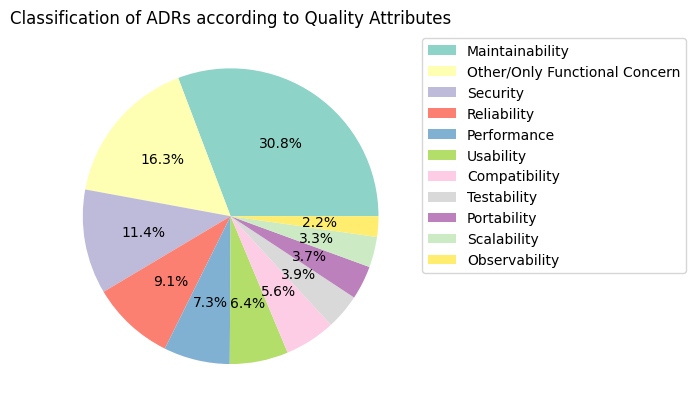

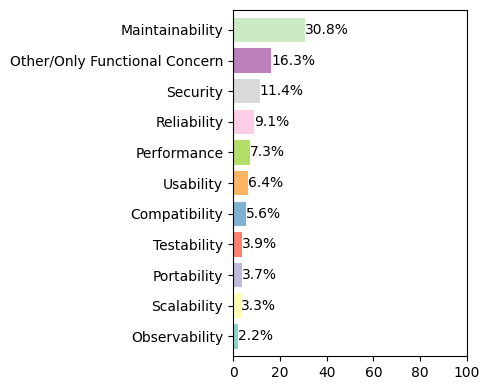

In [54]:
title = "Classification of ADRs according to Quality Attributes"

create_pie_chart(qas_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(qas_df, palette=COMMON_PALETTE, title="", fig_size=(5,4))

---

### **Classification using Zimmermann Taxonomy**

In [55]:
with open(ZIMMERMANN_RESULTS,'rb') as file:
    zimmermann_classification_dict_list = json.load(file)

print(len(zimmermann_classification_dict_list), "ADRs")
zimmermann_classification_dict_list[0:5]

4210 ADRs


[{'framework': 'zimmermann',
  'primary_category': 'Organizational/Process',
  'explanation': 'The ADR focuses on the decision to use Architecture Decision Records (ADRs) as a process to document architectural decisions. This is about how the team organizes and records decisions, which is a team workflow/process decision rather than a design, technology, or infrastructure choice. It does not concern system structure, technology selection, or deployment environment, but rather the process of decision documentation, fitting the Organizational/Process category. Other categories like Design or Technology are less appropriate because the ADR is not about system structure or technology selection. Constraint is not applicable as this is a chosen process, not a mandatory imposed rule.',
  'primary_score': 0.85,
  'alternative_categories': ['Design', 'Constraint'],
  'alternative_confidence_scores': [0.1, 0.05],
  'metadata': {'organization': 'navikt',
   'project': 'nada-kafkarator',
   'adr_k

In [56]:
# zimmermann_df = pd.DataFrame(zimmermann_classification_dict_list)
zimmermann_df = pd.json_normalize(zimmermann_classification_dict_list)
zimmermann_df

,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,zimmermann,Organizational/Process,The ADR focuses on the decision to use Archite...,0.85,"[Design, Constraint]","[0.1, 0.05]",navikt,nada-kafkarator,0001-record-architecture-decisions.md
1,zimmermann,Technology,The ADR focuses on the selection of Python as ...,0.85,"[Organizational/Process, Implementation]","[0.1, 0.05]",navikt,nada-kafkarator,0002-use-python.md
2,zimmermann,Technology,The ADR focuses on selecting Poetry as the dep...,0.90,[Infrastructure],[0.1],navikt,nada-kafkarator,0003-use-poetry-for-dependency-management.md
3,zimmermann,Design,The ADR discusses the architectural decision t...,0.85,[Implementation],[0.15],navikt,nada-kafkarator,0004-combine-topic-creation-and-credentials-ma...
4,zimmermann,Technology,The ADR focuses on selecting a web framework (...,0.85,"[Design, Quality Attribute]","[0.1, 0.05]",navikt,nada-kafkarator,0005-use-the-fastapi-web-framework.md
...,...,...,...,...,...,...,...,...,...
4205,zimmermann,Organizational/Process,The ADR focuses on how to manage third-party c...,0.85,"[Technology, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0007-layers-as-git-submodules.md
4206,zimmermann,Infrastructure,The ADR describes a deployment and runtime env...,0.85,"[Quality Attribute, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0008-dual-root-with-data-volume.md
4207,zimmermann,Infrastructure,The ADR focuses on placing Docker's state dire...,0.85,[Technology],[0.15],Internet-of-People,titania-os,0009-docker-state-directory-on-data-volume.md
4208,zimmermann,Organizational/Process,The ADR decision is about linking the project'...,0.85,"[Technology, Design]","[0.1, 0.05]",Internet-of-People,titania-os,0010-wiki-as-submodule.md


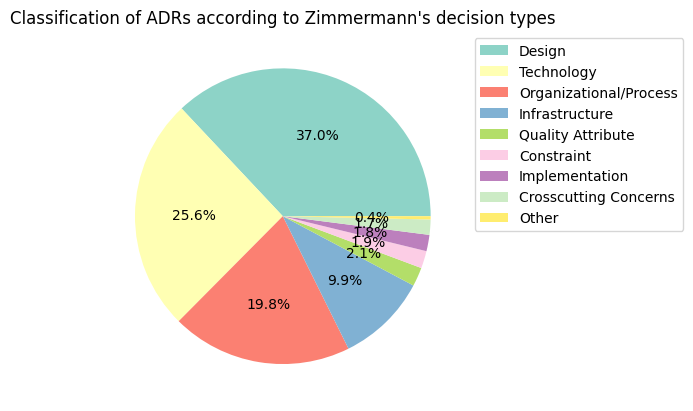

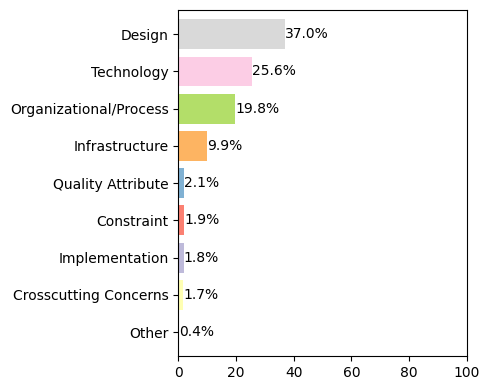

In [57]:
title = "Classification of ADRs according to Zimmermann's decision types"

create_pie_chart(zimmermann_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(zimmermann_df, palette=COMMON_PALETTE, title="", fig_size=(5,4))

---

### **Correlation Analyses**

In [58]:
krutchen_df = krutchen_df[['metadata.adr_key', 'primary_category']].dropna(axis=0)
print(krutchen_df.shape)
qas_df = qas_df[['metadata.adr_key', 'primary_category']].dropna(axis=0)
print(qas_df.shape)
zimmermann_df = zimmermann_df[['metadata.adr_key', 'primary_category']].dropna(axis=0)
print(zimmermann_df.shape)

zimmermann_df.rename(columns={'primary_category': 'zimmermann_primary_category', 'metadata.adr_key': 'adr_key'}, inplace=True)
qas_df.rename(columns={'primary_category': 'qa_primary_category', 'metadata.adr_key': 'adr_key'}, inplace=True)
krutchen_df.rename(columns={'primary_category': 'krutchen_primary_category', 'metadata.adr_key': 'adr_key'}, inplace=True)

# krutchen_df['adr'] = krutchen_df['metadata'].map(lambda x: x['adr'])
# qas_df['adr'] = qas_df['metadata'].map(lambda x: x['adr'])
# zimmermann_df['adr'] = zimmermann_df['metadata'].map(lambda x: x['adr'])

# krutchen_df.drop('metadata', axis=1, inplace=True)
# qas_df.drop('metadata', axis=1, inplace=True)
# zimmermann_df.drop('metadata', axis=1, inplace=True)

(4213, 2)
(4316, 2)
(4210, 2)


In [59]:
# krutchen_df

In [60]:
mg = pd.concat([zimmermann_df, krutchen_df, qas_df], axis=1)
mg


,adr_key,zimmermann_primary_category,adr_key,krutchen_primary_category,adr_key,qa_primary_category
0,0001-record-architecture-decisions.md,Organizational/Process,0001-use-architectural-decision-records.md,Executive (pericrisis),0001-Extend_vertx_launcher_for_CLI.md,Maintainability
1,0002-use-python.md,Technology,0002-use-husky-for-git-hooks.md,Executive (pericrisis),0002-Use_swagger_annotations_for_generating_cl...,Maintainability
2,0003-use-poetry-for-dependency-management.md,Technology,0003-use-commitizen-commitlint.md,Executive (pericrisis),0003-Pipeline_API_Rewrite.md,Maintainability
3,0004-combine-topic-creation-and-credentials-ma...,Design,0004-use-standard-version-for-versioning.md,Executive (pericrisis),0004-Graph_pipelines.md,Maintainability
4,0005-use-the-fastapi-web-framework.md,Technology,0005-use-typescript-in-javascript-projects.md,Executive (pericrisis),0005-Packaging_System_Design.md,Usability
...,...,...,...,...,...,...
4311,NaN,NaN,NaN,NaN,0007-use-ant-design-landing-to-create-the-land...,Maintainability
4312,NaN,NaN,NaN,NaN,0008-use-launchaco-com-to-generate-the-logo-fo...,Other/Only Functional Concern
4313,NaN,NaN,NaN,NaN,0009-use-cypress-for-e2e-testing.md,Testability
4314,NaN,NaN,NaN,NaN,0010-use-aws-amplify-coginito-for-login-and-th...,Security


In [61]:
def create_nodes_and_flows(df: pd.DataFrame, column1: str, column2: str):
    values1 = list(mg[column1].unique())
    values2 = list(mg[column2].unique())

    total = df.shape[0]
    nodes1 = [(idx, int(100*value/total)) for idx, value in df[column1].value_counts().items()]
    nodes2 = [(idx, int(100*value/total)) for idx, value in df[column2].value_counts().items()]

    nodes = [nodes1, nodes2]
    flows = []
    for pair in product(values2, values1):
        n = df[(df[column2] == pair[0]) & (df[column1] == pair[1])].shape[0]
        percentage = int(n / total * 100)
        if n > 0:
            flows.append((pair[1], pair[0], percentage))

    return nodes, flows

def make_sankey(nodes, flows, palette, title: str="", figsize=(10, 10), fontsize=12):
    plt.figure(figsize=figsize, dpi=144)
    s = Sankey(flows=flows, flow_color_mode='lesser', nodes=nodes, cmap=palette, node_opts=dict(label_format='{label} {value}%',label_opts=dict(fontsize=fontsize)))  # {value:.1f}%')) 
    s.draw()
    plt.title(title, fontsize=15)
    plt.show()


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sankeyflow/sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


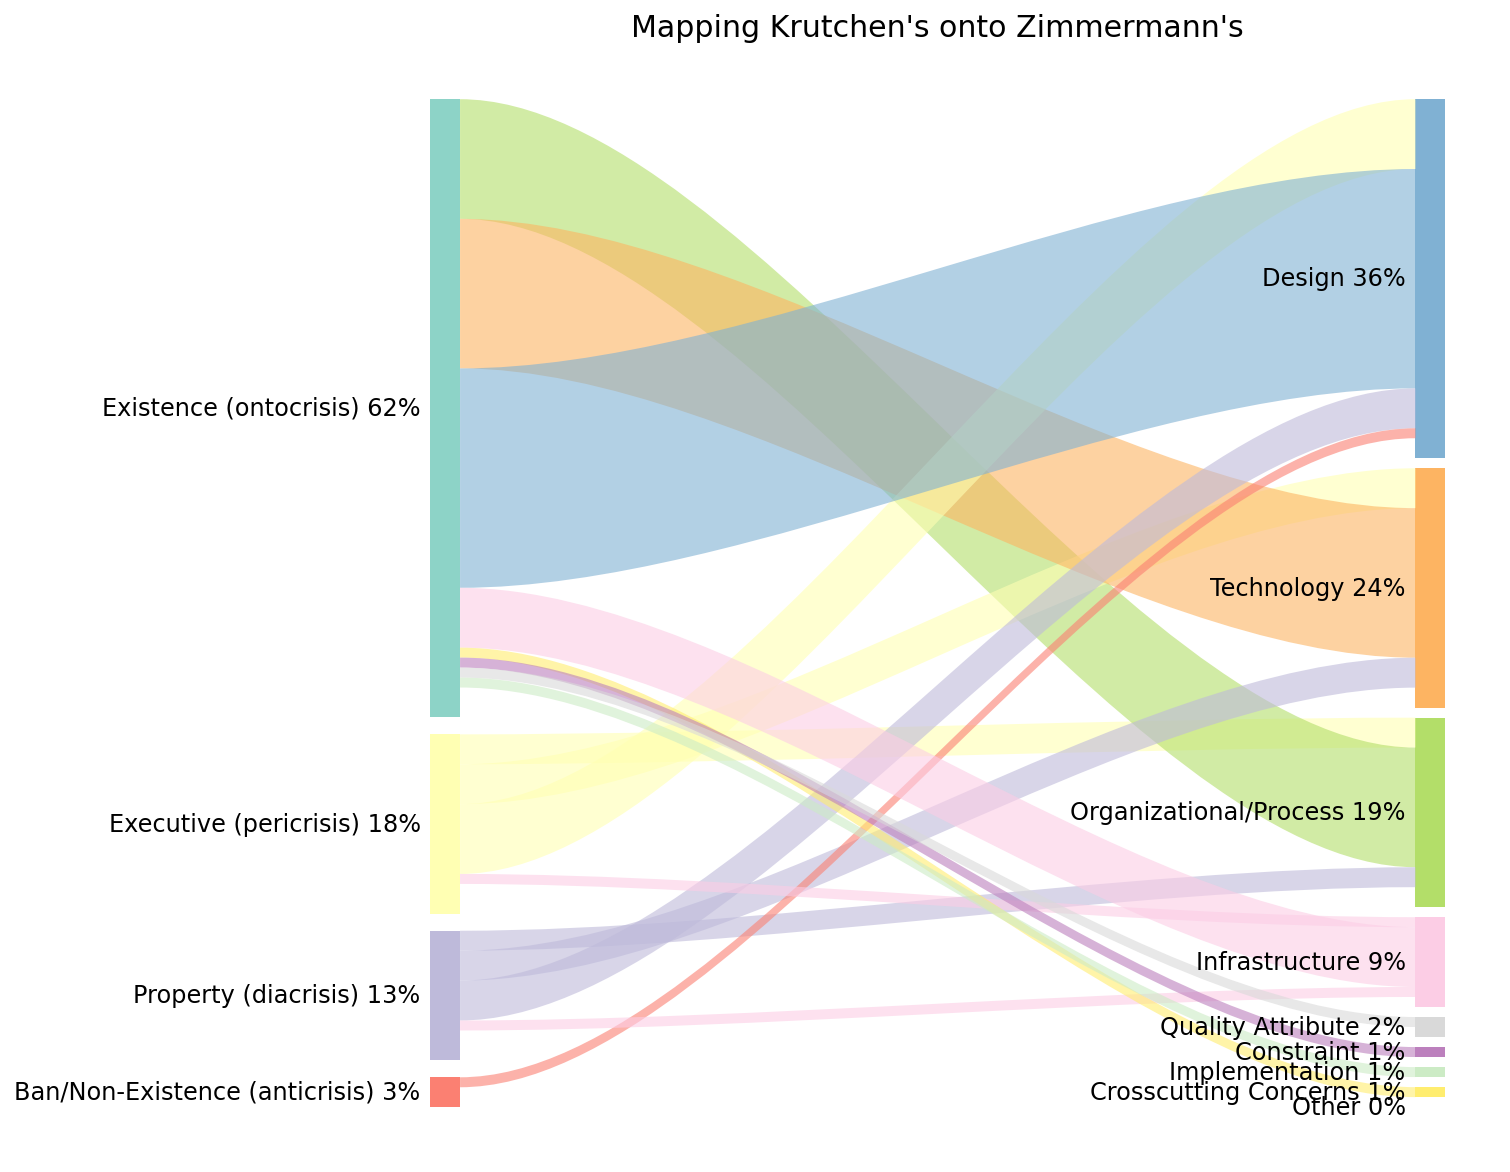

In [62]:
nodes1, flows1 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'zimmermann_primary_category')

title = "Mapping Krutchen's onto Zimmermann's"
make_sankey(nodes1, flows1, palette=COMMON_PALETTE, title=title)

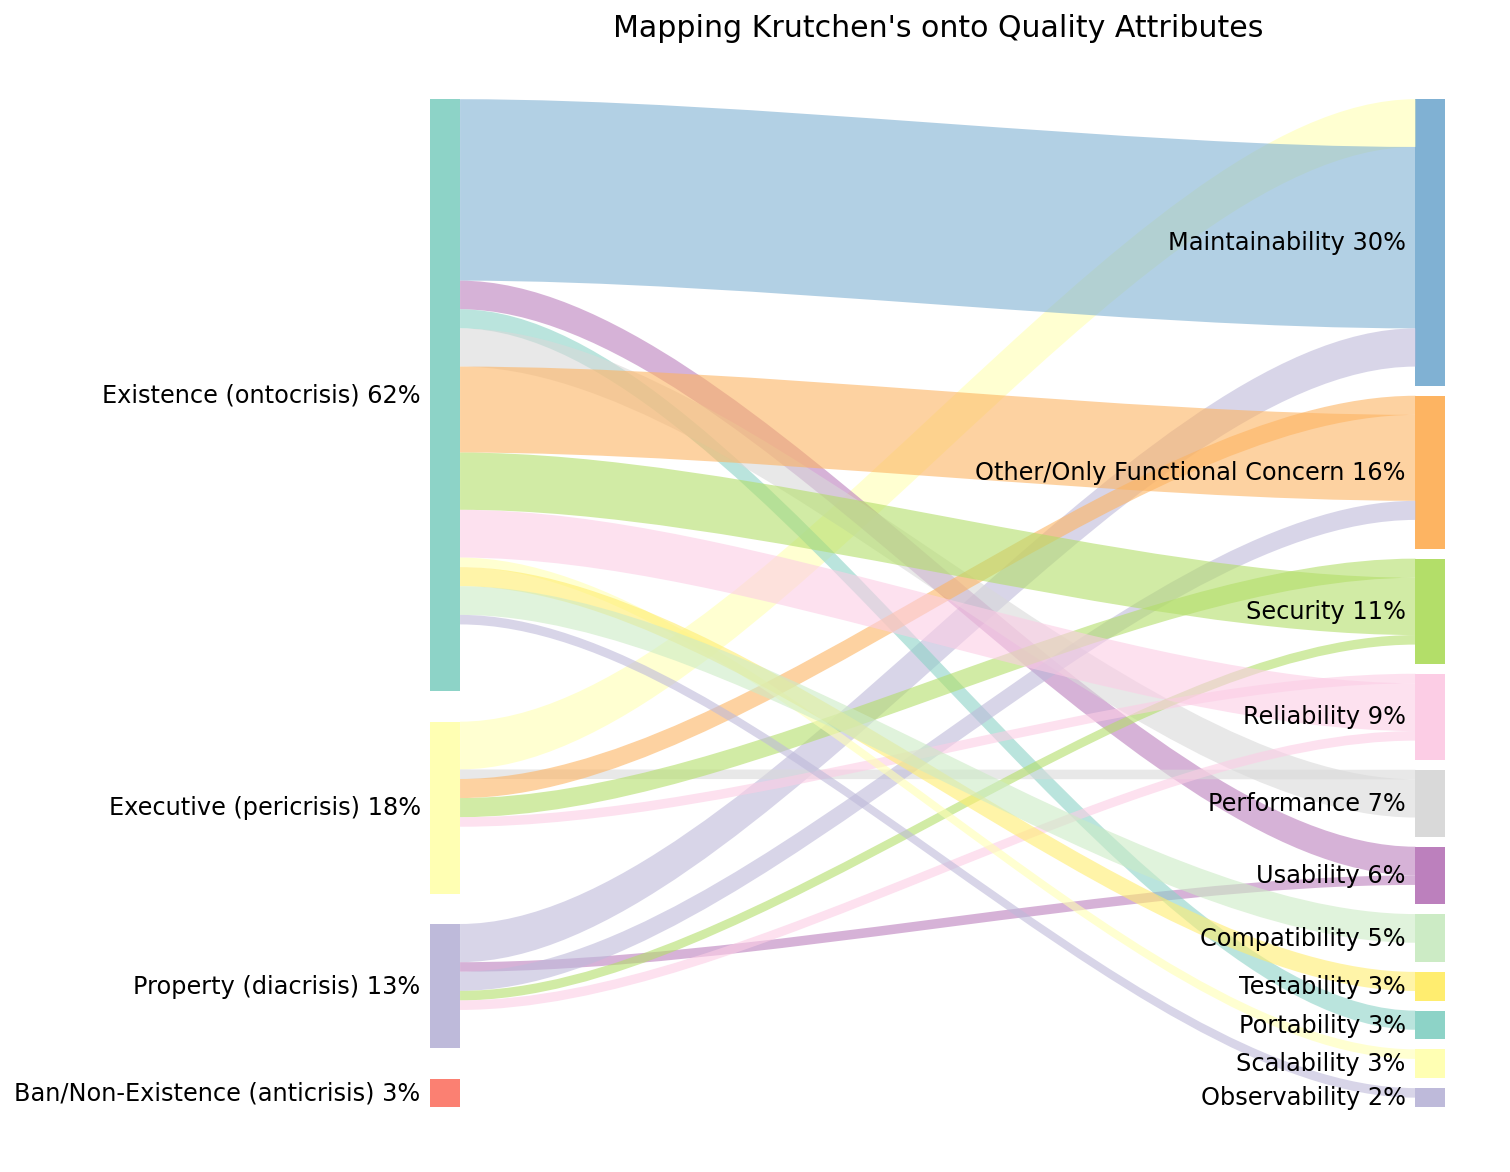

In [63]:
nodes2, flows2 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'qa_primary_category')

title = "Mapping Krutchen's onto Quality Attributes"
make_sankey(nodes2, flows2, palette=COMMON_PALETTE, title=title)

/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sankeyflow/sankeyflow.py:72: RuntimeWarning: invalid value encountered in scalar divide
  value_scale = self.value / (self.height - self.flow_pad * (len(flows) - 1))


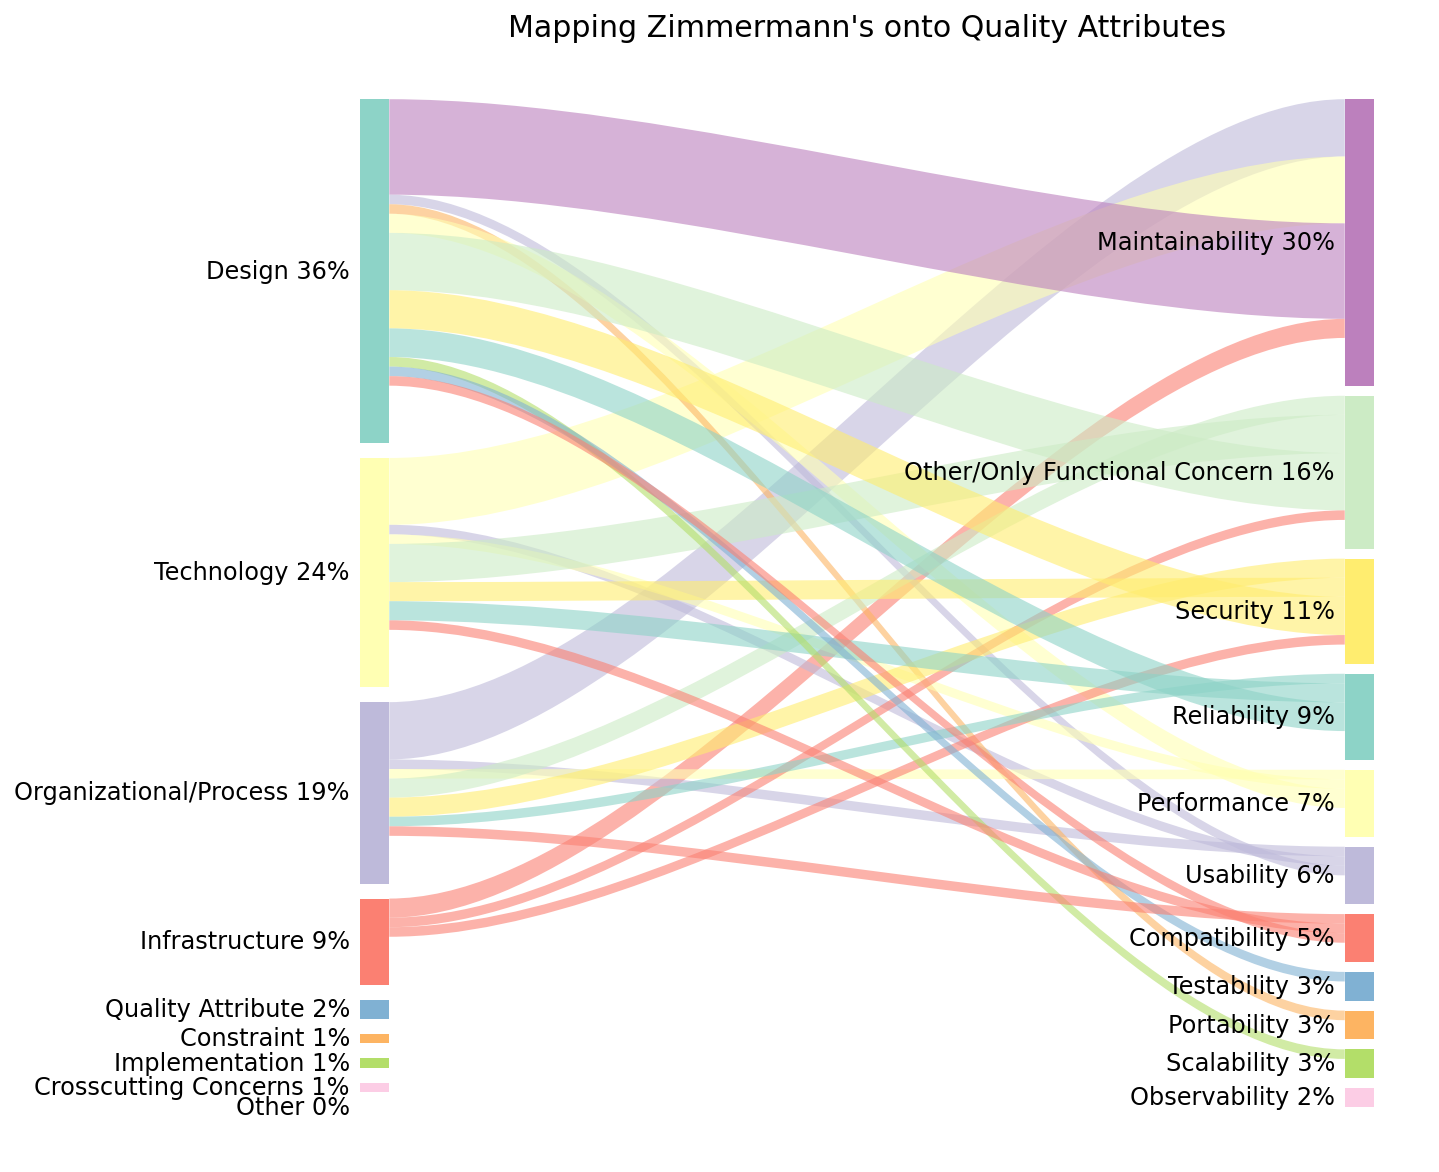

In [64]:
nodes3, flows3 = create_nodes_and_flows(mg, 'zimmermann_primary_category', 'qa_primary_category')

title = "Mapping Zimmermann's onto Quality Attributes"
make_sankey(nodes3, flows3, palette=COMMON_PALETTE, title=title)

In [65]:
with open(TOPICS_RESULTS,'rb') as file:
    topics_dict_list = json.load(file)
topics_dict_list[0:5]

[{'text': '# Use Markdown Architectural Decision Records\n\n## Context and Problem Statement\n\nWe want to record architectural decisions made in this project.\nWhich format and structure should these records follow?\n\n## Considered Options\n\n* [MADR](https://adr.github.io/madr/) 2.1.2 – The Markdown Architectural Decision Records\n* [Michael Nygard\'s template](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions) – The first incarnation of the term "ADR"\n* [Sustainable Architectural Decisions](https://www.infoq.com/articles/sustainable-architectural-design-decisions) – The Y-Statements\n* Other templates listed at <https://github.com/joelparkerhenderson/architecture_decision_record>\n* Formless – No conventions for file format and structure\n\n## Decision Outcome\n\nChosen option: "MADR 2.1.2", because\n\n* Implicit assumptions should be made explicit.\nDesign documentation is important to enable people understanding the decisions later on.\nSee also [A rat

In [66]:
topics_df = pd.json_normalize(topics_dict_list)
topics_df['keywords'] = topics_df['keywords'].apply(lambda x: x[0])
topics_df['keybert_representation'] = topics_df['keybert_representation'].apply(lambda x: x[0])
topics_df['openai_representation'] = topics_df['openai_representation'].apply(lambda x: x[0])

print(len(topics_df['openai_representation'].unique()), "topics identified in ADRs")
topics_df

73 topics identified in ADRs


,text,topics,keywords,keybert_representation,openai_representation,probabilities,metadata.organization,metadata.project,metadata.adr_key
0,# Use Markdown Architectural Decision Records\...,[2],"[architecture_decision_record, adrs, adr, arch...",2_architecture_decision_record_adrs_adr_archit...,Frontend architecture and UI component redesign,[0.7749036550521851],VolleyManagement,volley-management,0000-use-markdown-architectural-decision-recor...
1,# Use Auth0 as authentication provider\n\n* St...,[10],"[authentication, oauth2, authenticate, oauth, ...",10_authentication_oauth2_authenticate_oauth,Cosmos SDK Module Interactions and Encoding St...,[0.6686123609542847],VolleyManagement,volley-management,0001-use-auth0-as-authentication-provider.md
2,# Use SendGrid for sending emails\n\n* Status:...,[27],"[notifications, emails, alerts, notification, ...",27_notifications_emails_alerts_notification,iOS Build Modernization and Testing Best Pract...,[0.5629212260246277],VolleyManagement,volley-management,0002-use-sendgrid-as-mailing-system.md
3,# Use Angular Framework for VolleyManagement.S...,[42],"[apis, azure, apigee, api, gateway, cloud, ope...",42_apis_azure_apigee_api,JavaScript Code Style and Linting Enforcement,[0.35858237743377686],VolleyManagement,volley-management,0003-use-angular-for-spa.md
4,# Use Docker for hosting application\n\n* Stat...,[5],"[docker, dockerfiles, dockerfile, containers, ...",5_docker_dockerfiles_dockerfile_containers,Software Release Management and Branching Stra...,[0.6405783891677856],VolleyManagement,volley-management,0004-use-docker-for-hosting-application.md
...,...,...,...,...,...,...,...,...,...
4311,# Keep lines within sections of EditorConfig s...,[29],"[commits, prettier, github, git, formatter, de...",29_commits_prettier_github_git,API Access Control and Authorization Strategies,[0.5680497288703918],qbit86,arborescence,0001-keep-editorconfig-sorted.md
4312,# Configure line endigs in a .gitattributes fi...,[29],"[commits, prettier, github, git, formatter, de...",29_commits_prettier_github_git,API Access Control and Authorization Strategies,[0.5891322493553162],qbit86,arborescence,0002-configure-line-endings-in-gitattributes.md
4313,# Place using directives inside a namespace\n\...,[12],"[plugins, plugin, elektra, global, kdbopen, co...",12_plugins_plugin_elektra_global,AWS S3-Based File Uploads and Access Control,[0.3330201804637909],qbit86,arborescence,0003-place-using-directives-inside-namespace.md
4314,---\nstatus: superseded by [ADR-0005](0005-res...,[48],"[features, feature, feature_next_22222, featur...",48_features_feature_feature_next_22222_feature...,Arachne Configuration and Data Management Stra...,[0.4346681535243988],qbit86,arborescence,0004-restrict-language-version-to-csharp-8.md


In [67]:
# TODO: Work only with the top-k topics (by threshold)
# TODO: Use Cramer's V to measure association between variables, and also identify the most prevalent (pairs) of associations 
# using a contingency table

In [68]:
threshold_percentage = 0.02 # 1% threshold

frequencies = topics_df['openai_representation'].value_counts(normalize=True)
infrequent_values = frequencies[frequencies < threshold_percentage].index

# 3. Replace infrequent values with a common value using .mask()
# Map the original values to their frequencies, then use mask where frequency < threshold
topics_df['openai_representation_cleaned'] = topics_df['openai_representation'].mask(topics_df['openai_representation'].isin(infrequent_values), 'Others')

# print("Original value counts:")
# print(topics_df['openai_representation'].value_counts())
# print(f"\nCleaned value counts (threshold {threshold_percentage*100}%):")
# print(topics_df['openai_representation_cleaned'].value_counts())

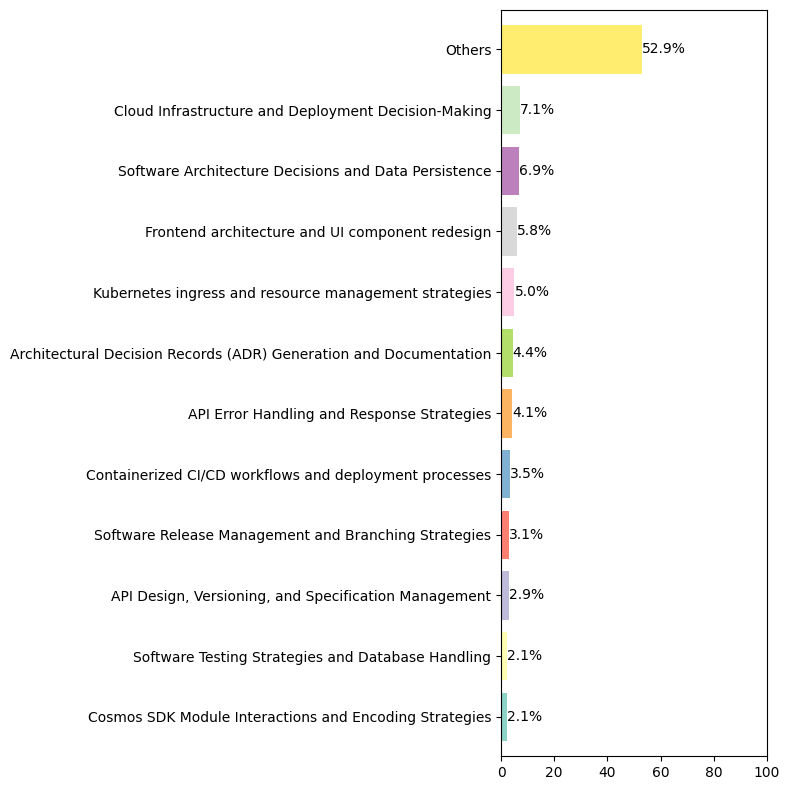

In [69]:
# create_pie_chart(topics_df, palette=COMMON_PALETTE, category_column='openai_representation', show_legend=True, title=title)
create_bar_chart(topics_df, palette=COMMON_PALETTE, category_column='openai_representation_cleaned', fig_size=(8,8))

In [70]:
topics_df = topics_df[['text', 'openai_representation_cleaned']].dropna(axis=0)
print(topics_df.shape)
topics_df.rename(columns={'openai_representation_cleaned': 'topics_primary_category', 'text': 'adr'}, inplace=True)

(4316, 2)


In [71]:
mg = pd.concat([zimmermann_df, krutchen_df, qas_df, topics_df], axis=1)
mg

,adr_key,zimmermann_primary_category,adr_key,krutchen_primary_category,adr_key,qa_primary_category,adr,topics_primary_category
0,0001-record-architecture-decisions.md,Organizational/Process,0001-use-architectural-decision-records.md,Executive (pericrisis),0001-Extend_vertx_launcher_for_CLI.md,Maintainability,# Use Markdown Architectural Decision Records\...,Frontend architecture and UI component redesign
1,0002-use-python.md,Technology,0002-use-husky-for-git-hooks.md,Executive (pericrisis),0002-Use_swagger_annotations_for_generating_cl...,Maintainability,# Use Auth0 as authentication provider\n\n* St...,Cosmos SDK Module Interactions and Encoding St...
2,0003-use-poetry-for-dependency-management.md,Technology,0003-use-commitizen-commitlint.md,Executive (pericrisis),0003-Pipeline_API_Rewrite.md,Maintainability,# Use SendGrid for sending emails\n\n* Status:...,Others
3,0004-combine-topic-creation-and-credentials-ma...,Design,0004-use-standard-version-for-versioning.md,Executive (pericrisis),0004-Graph_pipelines.md,Maintainability,# Use Angular Framework for VolleyManagement.S...,Others
4,0005-use-the-fastapi-web-framework.md,Technology,0005-use-typescript-in-javascript-projects.md,Executive (pericrisis),0005-Packaging_System_Design.md,Usability,# Use Docker for hosting application\n\n* Stat...,Software Release Management and Branching Stra...
...,...,...,...,...,...,...,...,...
4311,NaN,NaN,NaN,NaN,0007-use-ant-design-landing-to-create-the-land...,Maintainability,# Keep lines within sections of EditorConfig s...,Others
4312,NaN,NaN,NaN,NaN,0008-use-launchaco-com-to-generate-the-logo-fo...,Other/Only Functional Concern,# Configure line endigs in a .gitattributes fi...,Others
4313,NaN,NaN,NaN,NaN,0009-use-cypress-for-e2e-testing.md,Testability,# Place using directives inside a namespace\n\...,Others
4314,NaN,NaN,NaN,NaN,0010-use-aws-amplify-coginito-for-login-and-th...,Security,---\nstatus: superseded by [ADR-0005](0005-res...,Others


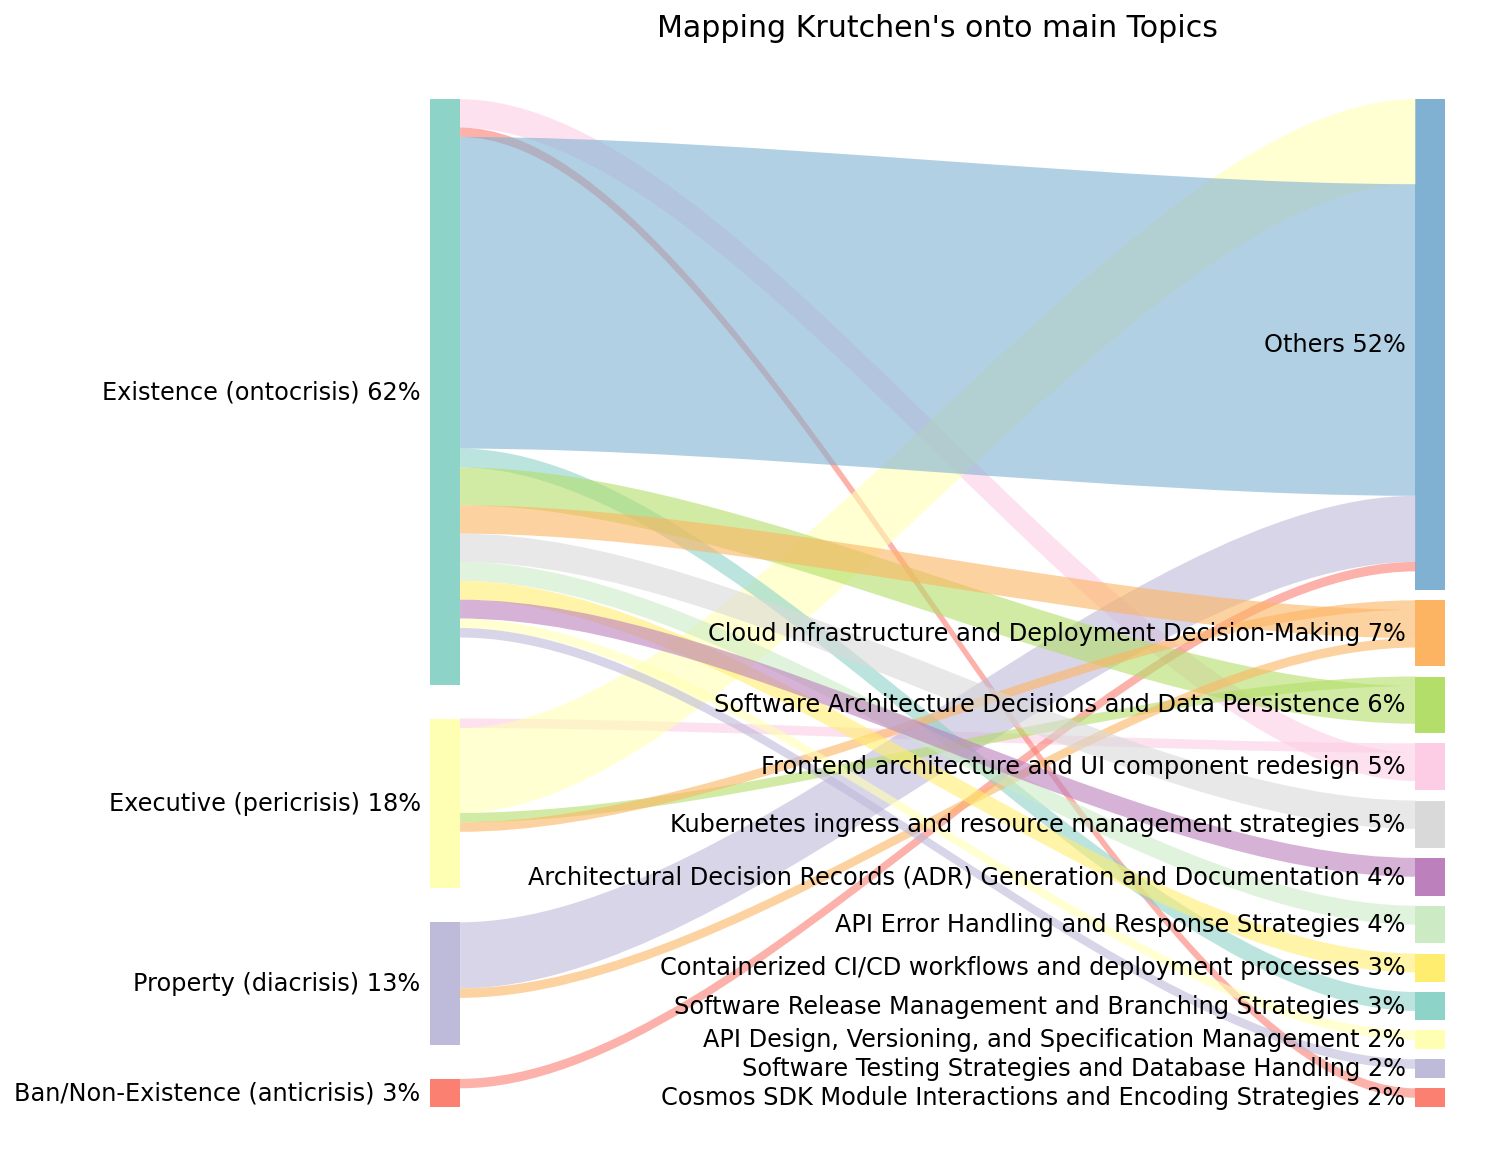

In [72]:
nodes4, flows4 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'topics_primary_category')

title = "Mapping Krutchen's onto main Topics"
make_sankey(nodes4, flows4, palette=COMMON_PALETTE, title=title)

---

### **MADR Template Checks**

In [73]:
with open(COMPLIANCE_RESULTS,'rb') as file:
    compliance_classification_dict_list = json.load(file)

print(len(compliance_classification_dict_list), "ADRs")
compliance_classification_dict_list[0:5]


4209 ADRs


[{'section_assessments': [{'section_name': 'Context',
    'presence': 'Yes',
    'content_quality': 'No',
    'purpose_consistency': 'Yes',
    'justification': "The ADR includes a section titled 'Context', so presence is 'Yes'. However, the content is minimal and generic: 'We need to record the architectural decisions made on this project.' This is a vague statement and does not provide meaningful, project-specific background, system state, problem, or motivation. Despite the minimal content, it does not include detailed comparisons, rationales, or final decisions, so the purpose consistency is 'Yes'. There are no alternate titles fulfilling this role, so the list is empty.",
    'alternate_title': []},
   {'section_name': 'Decision',
    'presence': 'Yes',
    'content_quality': 'Yes',
    'purpose_consistency': 'Yes',
    'justification': "The ADR includes a section titled exactly 'Decision', fulfilling the presence criterion. The content clearly states the final choice made: to use

In [90]:
def check_alternate_title(row, col):
    prefix = col.split('.')[0]
    presence_col = prefix + '.presence'
    # print(row[presence_col], row[col])
    if row[presence_col] == 'No':
        return False if isinstance(row, list) and len(row) == 0 else True
    return False

def summarize_results(df: pd.DataFrame, selector, n_decimals=2, 
                      adr_sections=['context', 'drivers', 'decision', 'consequences', 'options'], 
                      criteria=['alternative title?', 'content quality', 'present?', 'purpose consistency']):
    aspects_df = df[selector]
    # If a column name ends with alternate_title and has an empty list replace with True, or False otherwise
    aspects_df = aspects_df.copy() # Avoid SettingWithCopyWarning
    alternate_title_cols = [col for col in aspects_df.columns if col.endswith('alternate_title')]
    for col in alternate_title_cols:
        # aspects_df[col] = aspects_df[col].apply(lambda x: False if isinstance(x, list) and len(x) == 0 else True)
        aspects_df[col] = aspects_df.apply(lambda row: check_alternate_title(row, col), axis=1)

    # Substitute Yes/No with True/False
    aspects_df = aspects_df.replace({'Yes': True, 'No': False, 'Partial': True}).astype(bool)
    # Count the number of True values in each column
    aspects_series = aspects_df.sum(axis=0)
    # Create a multi-index by spliting the series index by '.'
    aspects_series.index = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in aspects_series.index])
    results_df = aspects_series.unstack() / aspects_df.shape[0] * 100 
    results_df.columns = criteria
    results_df = results_df.round(n_decimals).reindex(adr_sections)
    
    return results_df

def create_heatmap(df, figsize=(10, 8), title="", fontsize=10,
    criteria_order=['present?', 'alternative title?', 'content quality', 'purpose consistency']):
    # Create the heatmap
    plt.figure(figsize=figsize) # Adjust figure size as needed
    # Use a color scale from light red to light green # cmap="RdYlGn"
    ax = sns.heatmap(df[criteria_order], annot=True, cmap="YlGn", 
                     fmt=".2f", linewidths=.5, cbar_kws={"label": "Percentage (%)"}, 
                     vmax=100, vmin=0, annot_kws={'size': fontsize}) 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=fontsize*0.8) # Set the rotation for the y-axis tick labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fontsize*0.8)
    # plt.xlabel("Columns")
    # plt.ylabel("Rows")
    plt.title(title)
    plt.show()

In [75]:
# Flatten the JSON structure
compliance_df = pd.json_normalize(compliance_classification_dict_list)
                                  
section_assessments_df = pd.json_normalize(compliance_df['section_assessments'])
adr_sections = ['context', 'decision', 'consequences', 'drivers', 'options']
section_assessments_df.columns = adr_sections
section_dfs = []
for col in adr_sections:
    section_df = pd.json_normalize(section_assessments_df[col]).add_prefix(col+'.')
    section_dfs.append(section_df)

compliance_flat_df = pd.concat([compliance_df.drop('section_assessments', axis=1)]+section_dfs, axis=1)
compliance_flat_df = compliance_flat_df.dropna(axis=0)
compliance_flat_df

,template_adherence.title,template_adherence.status,template_adherence.context,template_adherence.decision_drivers,template_adherence.decision,template_adherence.consequences,template_adherence.alternatives,template_adherence.date,template_adherence.adherence_score,template_adherence.assessment,...,drivers.content_quality,drivers.purpose_consistency,drivers.justification,drivers.alternate_title,options.section_name,options.presence,options.content_quality,options.purpose_consistency,options.justification,options.alternate_title
0,0. Record architecture decisions,accepted,We need to record the architectural decisions ...,,"We will use Architecture Decision Records, as ...","See Michael Nygard's article, linked above.",[],,0.83,- Title: Present and appropriate as the main h...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]
1,1. The Katas follow the here described formatting,accepted,I come back to the katas and my formatting sty...,,A kata looks like the following:\n\n```\ndescr...,All katas look alike and the users have one UX...,[],,0.70,- Title: Present and appropriate as the first ...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,There is no section titled 'Considered Options...,[]
2,Assessment of ADR '2. We don't use any linter'...,accepted,The ADR discusses the decision not to use a li...,The ADR considers the overhead of configuring ...,The decision is to not use a linter but rely o...,"The consequence is that no linter is used, and...",[{'description': 'Use a traditional linter wit...,2024-06-10,0.80,- Title: Present and descriptive ('2. We don't...,...,No,No,The ADR does not include a section titled 'Dec...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]
3,3. Katafication,accepted,All katas in here are supposed to be used to f...,,All tests have to pass and the special comment...,The tests can be used as tests and katas. Addi...,[],,0.71,"- Title: Present as '3. Katafication', which i...",...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,There is no section titled 'Considered Options...,[]
4,"4. In-depth katas are separated from ""normal"" ...",Accepted,I (Wolfram) am writing most of the katas and s...,- Need to handle different depths of katas (si...,Katas will come in two flavours: simple kata a...,- There will be more katas overall.\n- Simple ...,[{'description': 'Maintain a single kata per f...,2024-06-10,0.90,- Title: Present and appropriate as the main h...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,The ADR does not include a section titled 'Con...,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4204,6. Use Okta as Identity provider,Spiked - Delay for now,Okta is an Identity as a Service provider (sim...,The decision drivers include the need for a re...,The decision is to delay the adoption of Okta ...,The consequences include potential issues with...,[{'description': 'Continue using Microsoft as ...,2017-12-07,0.90,- Title: Present and appropriate as '6. Use Ok...,...,No,No,There is no section titled 'Decision Drivers' ...,[],Considered Options,No,No,No,There is no section titled 'Considered Options...,"[Context, Decision, Consequences]"
4205,7. Use Pac4J to validate tokens,Decline,http://www.pac4j.org\n\nWhile exporing alterna...,,* Use Pac4J to validate MS id_tokens instead o...,* Less unit testing on our end\n* Pac4J only s...,[{'description': 'Alternative to [5. Use id_to...,2017-12-07,0.75,- Title: Present and appropriate as a top-leve...,...,No,No,There is no section titled 'Decision Drivers' ...,[Context],Considered Options,No,No,No,There is no section titled 'Considered Options...,[]
4206,8. Database,accepted,"Bookit needs to persist the locations, bookabl...",The ADR does not explicitly list decision

In [76]:
# compliance_flat_df.columns

In [77]:
col_selector = ['context', 'drivers', 'decision', 'consequences', 'options']
aspects = ['presence', 'alternate_title', 'content_quality', 'purpose_consistency'] #, 'justification']
col_aspect_selector = [col + '.' + aspect for col in col_selector for aspect in aspects]
# col_aspect_selector

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_92489/2862606726.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aspects_df = aspects_df.replace({'Yes': True, 'No': False, 'Partial': True}).astype(bool)


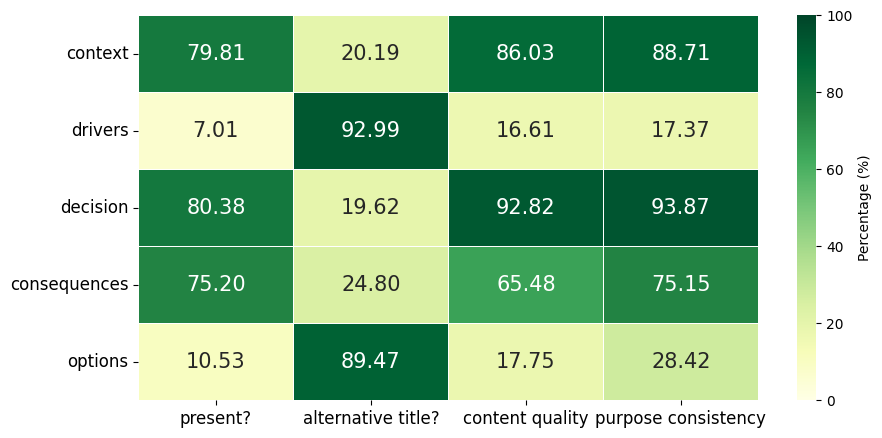

In [96]:
results_df = summarize_results(compliance_flat_df, col_aspect_selector)
create_heatmap(results_df, fontsize=15, figsize=(10,5))

In [43]:
results_df

,alternative title?,content quality,present?,purpose consistency
context,93.66,86.03,79.81,88.71
drivers,27.35,16.61,7.01,17.37
decision,16.32,92.82,80.38,93.87
consequences,11.36,65.48,75.20,75.15
options,27.73,17.75,10.53,28.42


---